# **BƯỚC 1: Kết nối Google Drive và Cấu hình**

In [46]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os

# CẤU HÌNH ĐƯỜNG DẪN (sửa ở đây nếu cần)
drive_data_path = '/content/drive/MyDrive/Project_CV/Student-engagement-dataset-clean'
model_path_h5 = '/content/drive/MyDrive/Project_CV/Student Engagement Model.h5'
svm_save_path = '/content/drive/MyDrive/Project_CV/svm_final_model.pkl'

print("Đã kết nối Drive thành công!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Đã kết nối Drive thành công!


## **BƯỚC 2: Tự động chia dữ liệu (80% Train - 20% Test)**

In [47]:
import shutil
import random

if os.path.exists(temp_dir):
    shutil.rmtree(temp_dir)

for root_folder in os.listdir(drive_data_path):
    root_path = os.path.join(drive_data_path, root_folder)
    if not os.path.isdir(root_path):
        continue

    for class_name in os.listdir(root_path):
        class_path = os.path.join(root_path, class_name)
        if not os.path.isdir(class_path):
            continue

        train_out = os.path.join(temp_dir, 'train', class_name)
        test_out  = os.path.join(temp_dir, 'test', class_name)
        os.makedirs(train_out, exist_ok=True)
        os.makedirs(test_out, exist_ok=True)

        images = [f for f in os.listdir(class_path)
                  if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
        random.shuffle(images)

        split = int(0.8 * len(images))
        for img in images[:split]:
            shutil.copy(os.path.join(class_path, img), os.path.join(train_out, img))
        for img in images[split:]:
            shutil.copy(os.path.join(class_path, img), os.path.join(test_out, img))

print("Dataset ready:", temp_dir)

Dataset ready: /content/temp_data


# **BƯỚC 3: Load CNN (file h5) & Cắt bỏ Softmax**

In [49]:
from tensorflow.keras.models import load_model, Model
import numpy as np

# Load model CNN đã train
cnn_model = load_model(model_path_h5)

# BẮT BUỘC call model 1 lần để build graph
_ = cnn_model(np.zeros((1, 128, 128, 1)))

# CẮT SOFTMAX ĐÚNG KERAS 3
feature_extractor = Model(
    inputs=cnn_model.inputs,
    outputs=cnn_model.layers[-2].output
)

print("Feature extractor output:", feature_extractor.output_shape)

Feature extractor output: (None, 512)


# **BƯỚC 4: Trích xuất đặc trưng (Feature Extraction)**

In [50]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import numpy as np

datagen = ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_directory(
    os.path.join(temp_dir, 'train'),
    target_size=(128, 128),
    color_mode='grayscale',
    batch_size=32,
    class_mode=None,
    shuffle=False
)

test_gen = datagen.flow_from_directory(
    os.path.join(temp_dir, 'test'),
    target_size=(128, 128),
    color_mode='grayscale',
    batch_size=32,
    class_mode=None,
    shuffle=False
)

def generator_to_numpy(generator):
    X = []
    for i in range(len(generator)):
        X.append(generator[i])
    X = np.vstack(X)
    y = generator.classes
    return X, y

X_train_img, y_train = generator_to_numpy(train_gen)
X_test_img,  y_test  = generator_to_numpy(test_gen)

print("Train images:", X_train_img.shape, y_train.shape)
print("Test images :", X_test_img.shape, y_test.shape)


Found 1694 images belonging to 6 classes.
Found 426 images belonging to 6 classes.
Train images: (1694, 128, 128, 1) (1694,)
Test images : (426, 128, 128, 1) (426,)


# **BƯỚC 5: Huấn luyện SVM & Lưu Model**

In [51]:
X_train = feature_extractor.predict(
    X_train_img,
    batch_size=32,
    verbose=1
)

X_test = feature_extractor.predict(
    X_test_img,
    batch_size=32,
    verbose=1
)

print("Train features:", X_train.shape, y_train.shape)
print("Test features :", X_test.shape, y_test.shape)


53/53 ━━━━━━━━━━━━━━━━━━━━ 48s 909ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 13s 916ms/step
Train features: (1694, 512) (1694,)
Test features : (426, 512) (426,)


In [44]:
from sklearn.svm import SVC
import joblib

svm_model = SVC(kernel='rbf', C=1.0)
svm_model.fit(X_train, y_train)

joblib.dump(svm_model, svm_save_path)
print("Train SVM xong & đã lưu model")

Train SVM xong & đã lưu model


# **BƯỚC 6: Đánh giá kết quả & Vẽ biểu đồ**

ĐỘ CHÍNH XÁC (Accuracy): 97.65%


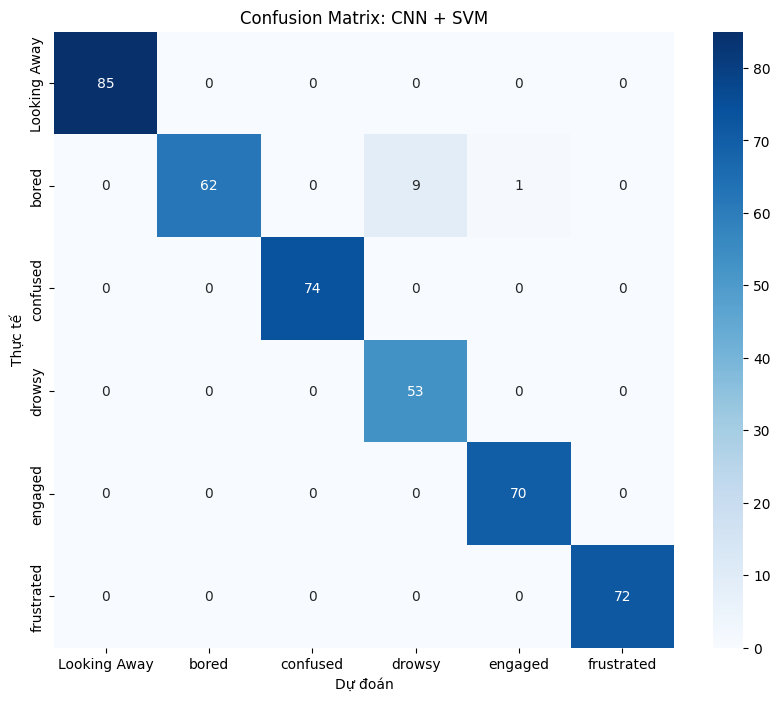


--- BÁO CÁO CHI TIẾT ---
              precision    recall  f1-score   support

Looking Away       1.00      1.00      1.00        85
       bored       1.00      0.86      0.93        72
    confused       1.00      1.00      1.00        74
      drowsy       0.85      1.00      0.92        53
     engaged       0.99      1.00      0.99        70
  frustrated       1.00      1.00      1.00        72

    accuracy                           0.98       426
   macro avg       0.97      0.98      0.97       426
weighted avg       0.98      0.98      0.98       426



In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Dự đoán thử trên tập Test
y_pred = svm_model.predict(X_test)

# 2. Tính độ chính xác
acc = accuracy_score(y_test, y_pred)
print(f"ĐỘ CHÍNH XÁC (Accuracy): {acc * 100:.2f}%")

# 3. Vẽ Ma trận nhầm lẫn (Confusion Matrix)
class_names = list(test_gen.class_indices.keys()) # Lấy tên các lớp (Bored, Engaged...)

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix: CNN + SVM')
plt.ylabel('Thực tế')
plt.xlabel('Dự đoán')
plt.show()

# 4. Báo cáo chi tiết
print("\n--- BÁO CÁO CHI TIẾT ---")
print(classification_report(y_test, y_pred, target_names=class_names))